### Step 1: Import Required Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Load and Preprocess the Dataset

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define paths to the dataset directories
dataset_path = '/content/drive/MyDrive/Plant_Disease_Detection_Project_2024/Plant_Disease_Detection_Dataset/Plant_Disease_Detection_Dataset_v3'

In [7]:
# Split the dataset into training and validation sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # Use 20% of the data for validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5448 images belonging to 35 classes.
Found 1362 images belonging to 35 classes.


### Step 3: Build and Train the MobileNetV2 Model

In [4]:
# Load the MobileNetV2 model, excluding the top layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)  # Fully connected layer
predictions = Dense(train_generator.num_classes, activation='softmax')(x)  # Final output layer

In [ ]:
# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# Freeze the base model layers to prevent them from being updated during the initial training
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
initial_epochs = 10
history = model.fit(
    train_generator,
    epochs=initial_epochs,
    validation_data=validation_generator
)

Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 1739s 10s/step - accuracy: 0.7968 - loss: 0.6483 - val_accuracy: 0.8399 - val_loss: 0.5034
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 106s 593ms/step - accuracy: 0.8716 - loss: 0.3744 - val_accuracy: 0.8532 - val_loss: 0.4614
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 125s 717ms/step - accuracy: 0.8894 - loss: 0.3248 - val_accuracy: 0.8157 - val_loss: 0.5892
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 106s 602ms/step - accuracy: 0.9061 - loss: 0.2736 - val_accuracy: 0.8590 - val_loss: 0.4642
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 140s 592ms/step - accuracy: 0.9169 - loss: 0.2416 - val_accuracy: 0.8656 - val_loss: 0.3976
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 142s 592ms/step - accuracy: 0.9286 - loss: 0.2159 - val_accuracy: 0.8950 - val_loss: 0.3207
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 142s 598ms/step - accuracy: 0.9285 - loss: 0.2150 - val_accuracy: 0.8781 - val_loss: 0.3949
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 142s 592ms/step - accuracy: 0.9293 - 

In [ ]:
model.save_weights('/content/drive/MyDrive/Plant_Disease_Detection_Project_2024/Plant_Disease_Detection.weights.h5')

### Step 5: Evaluate the Model

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 517ms/step - accuracy: 0.8773 - loss: 0.4021
Validation Accuracy: 86.71%


### Step 6: Visualize Training Progress

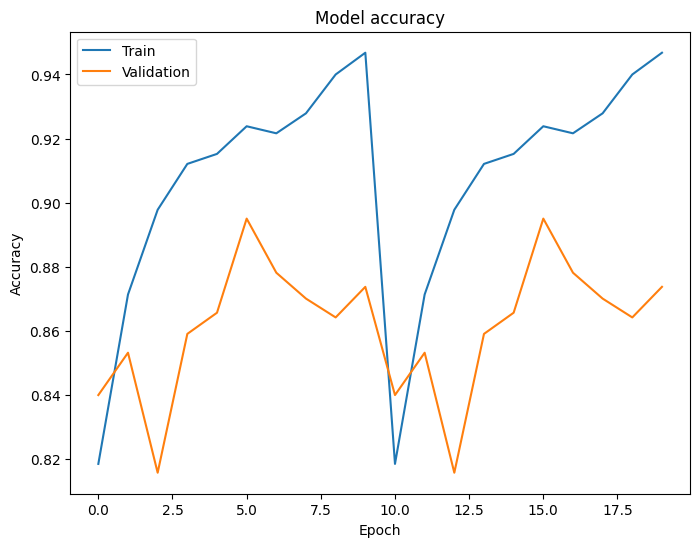

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'] + history.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

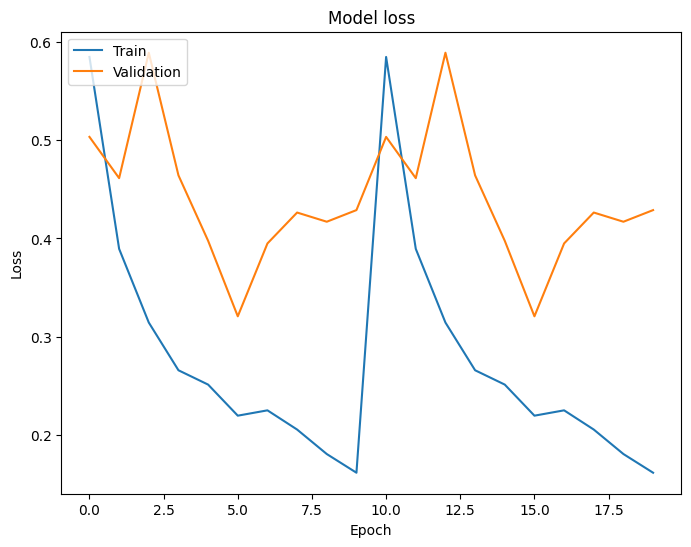

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'] + history.history['loss'])
plt.plot(history.history['val_loss'] + history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Provide inputs

Load the model

In [9]:
# Redefine the model architecture
#base_model = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Load the weights
model.load_weights('/content/drive/MyDrive/Plant_Disease_Detection_Project_2024/Plant_Disease_Detection.weights.h5')

Upload the Image

In [5]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

In [14]:
# Upload an image
uploaded = files.upload()

Saving Screenshot 2024-11-23 at 10.29.55 PM.png to Screenshot 2024-11-23 at 10.29.55 PM.png


In [15]:
# Load the uploaded image
for filename in uploaded.keys():
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize the image

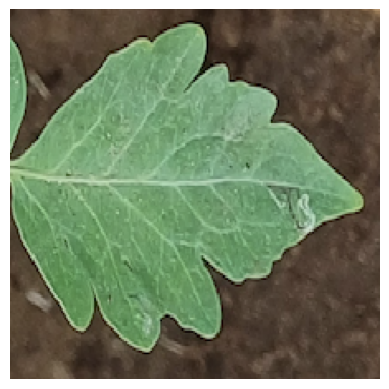

In [16]:
# Display the image
plt.imshow(img_array[0])
plt.axis('off')
plt.show()

Make a Prediction

In [17]:
# Make a prediction
predictions = model.predict(img_array)

# Get the class label with the highest predicted probability
predicted_class_index = np.argmax(predictions[0])
class_labels = list(train_generator.class_indices.keys())
predicted_class_label = class_labels[predicted_class_index]

print(f"Predicted class: {predicted_class_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted class: Tomato___healthy
